In [5]:
df = pd.read_csv("../data/raw/netflix1.csv")
df.head()


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [6]:
df.info()
df.isna().sum().sort_values(ascending=False)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8790 non-null   object
 1   type          8790 non-null   object
 2   title         8790 non-null   object
 3   director      8790 non-null   object
 4   country       8790 non-null   object
 5   date_added    8790 non-null   object
 6   release_year  8790 non-null   int64 
 7   rating        8790 non-null   object
 8   duration      8790 non-null   object
 9   listed_in     8790 non-null   object
dtypes: int64(1), object(9)
memory usage: 686.8+ KB


show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64

In [7]:
df["director"].value_counts().head(10)


director
Not Given                 2588
Rajiv Chilaka               20
Alastair Fothergill         18
Raúl Campos, Jan Suter      18
Marcus Raboy                16
Suhas Kadav                 16
Jay Karas                   14
Cathy Garcia-Molina         13
Jay Chapman                 12
Martin Scorsese             12
Name: count, dtype: int64

In [8]:
df["country"].value_counts().head(10)


country
United States     3240
India             1057
United Kingdom     638
Pakistan           421
Not Given          287
Canada             271
Japan              259
South Korea        214
France             213
Spain              182
Name: count, dtype: int64

In [9]:
df["director"] = df["director"].replace("Not Given", "Unknown")
df["country"] = df["country"].replace("Not Given", "Unknown")


In [12]:
df["director"].value_counts().head(5)
df["country"].value_counts().head(5)


country
United States     3240
India             1057
United Kingdom     638
Pakistan           421
Unknown            287
Name: count, dtype: int64

In [13]:
df["director"].value_counts().head(5)


director
Unknown                   2588
Rajiv Chilaka               20
Alastair Fothergill         18
Raúl Campos, Jan Suter      18
Marcus Raboy                16
Name: count, dtype: int64

In [14]:
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")
df["year_added"] = df["date_added"].dt.year


In [15]:
df[["date_added", "year_added"]].head()


,date_added,year_added
0,2021-09-25,2021
1,2021-09-24,2021
2,2021-09-24,2021
3,2021-09-22,2021
4,2021-09-24,2021


In [17]:
df["duration_num"] = df["duration"].str.extract(r"(\d+)").astype(int)
df["duration_type"] = df["duration"].str.extract(r"(min|Season|Seasons)", expand=False)


In [18]:
df[["type", "duration", "duration_num", "duration_type"]].head(10)


,type,duration,duration_num,duration_type
0,Movie,90 min,90,min
1,TV Show,1 Season,1,Season
2,TV Show,1 Season,1,Season
3,Movie,91 min,91,min
4,Movie,125 min,125,min
5,TV Show,9 Seasons,9,Season
6,Movie,104 min,104,min
7,Movie,87 min,87,min
8,Movie,127 min,127,min
9,Movie,76 min,76,min


In [19]:
import numpy as np

df["duration_type"] = df["duration_type"].str.lower()

df["movie_duration_min"] = np.where(df["type"].eq("Movie"), df["duration_num"], np.nan)

df["tv_seasons"] = np.where(df["type"].eq("TV Show"), df["duration_num"], np.nan)


In [20]:
df[["type", "duration", "duration_num", "duration_type", "movie_duration_min", "tv_seasons"]].head(12)


,type,duration,duration_num,duration_type,movie_duration_min,tv_seasons
0,Movie,90 min,90,min,90.0,NaN
1,TV Show,1 Season,1,season,NaN,1.0
2,TV Show,1 Season,1,season,NaN,1.0
3,Movie,91 min,91,min,91.0,NaN
4,Movie,125 min,125,min,125.0,NaN
5,TV Show,9 Seasons,9,season,NaN,9.0
6,Movie,104 min,104,min,104.0,NaN
7,Movie,87 min,87,min,87.0,NaN
8,Movie,127 min,127,min,127.0,NaN
9,Movie,76 min,76,min,76.0,NaN


In [21]:
df["movie_duration_min"].describe()
df["tv_seasons"].describe()


count    2664.000000
mean        1.751877
std         1.550622
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        17.000000
Name: tv_seasons, dtype: float64

In [24]:
from pathlib import Path

out_dir = Path("data/prepared")
out_dir.mkdir(parents=True, exist_ok=True)

df.to_csv(out_dir / "netflix_clean.csv", index=False)


In [ ]:
import sqlite3
from pathlib import Path

db_path = Path("../data/dw/netflix.db")
db_path.parent.mkdir(parents=True, exist_ok=True)

conn = sqlite3.connect(db_path)
conn.close()

print("DB created at:", db_path.resolve())


DB created at: C:\Users\sabri\projects\netflix-analysis\data\dw\netflix.db


In [29]:
import os

os.makedirs("../data/prepared", exist_ok=True)

df.to_csv("../data/prepared/netflix_clean.csv", index=False)

print("Saved:", os.path.exists("../data/prepared/netflix_clean.csv"))


Saved: True


In [30]:
import sqlite3
import pandas as pd
from pathlib import Path

db_path = Path("../data/dw/netflix.db")

df_clean = pd.read_csv("../data/prepared/netflix_clean.csv")

conn = sqlite3.connect(db_path)
df_clean.to_sql("netflix_titles", conn, if_exists="replace", index=False)

pd.read_sql_query("SELECT COUNT(*) AS rows FROM netflix_titles;", conn)


,rows
0,8790


In [31]:
pd.read_sql_query("""
SELECT
    type,
    COUNT(*) AS total_titles
FROM netflix_titles
GROUP BY type;
""", conn)


,type,total_titles
0,Movie,6126
1,TV Show,2664


In [32]:
pd.read_sql_query("""
SELECT
    year_added,
    COUNT(*) AS titles_added
FROM netflix_titles
WHERE year_added IS NOT NULL
GROUP BY year_added
ORDER BY year_added;
""", conn)


,year_added,titles_added
0,2008,2
1,2009,2
2,2010,1
3,2011,13
4,2012,3
5,2013,11
6,2014,24
7,2015,82
8,2016,426
9,2017,1185


In [33]:
pd.read_sql_query("""
SELECT
    country,
    COUNT(*) AS total_titles
FROM netflix_titles
WHERE country IS NOT NULL
GROUP BY country
ORDER BY total_titles DESC
LIMIT 10;
""", conn)


,country,total_titles
0,United States,3240
1,India,1057
2,United Kingdom,638
3,Pakistan,421
4,Unknown,287
5,Canada,271
6,Japan,259
7,South Korea,214
8,France,213
9,Spain,182


In [34]:
pd.read_sql_query("""
SELECT
    rating,
    COUNT(*) AS total_titles
FROM netflix_titles
GROUP BY rating
ORDER BY total_titles DESC;
""", conn)


,rating,total_titles
0,TV-MA,3205
1,TV-14,2157
2,TV-PG,861
3,R,799
4,PG-13,490
5,TV-Y7,333
6,TV-Y,306
7,PG,287
8,TV-G,220
9,NR,79


In [35]:
pd.read_sql_query("""
SELECT
    ROUND(AVG(duration_num), 2) AS avg_movie_duration_min
FROM netflix_titles
WHERE type = 'Movie'
  AND duration_type = 'min';
""", conn)


,avg_movie_duration_min
0,99.58


In [36]:
pd.read_sql_query("""
SELECT
    MIN(duration_num) AS shortest_movie_min,
    MAX(duration_num) AS longest_movie_min
FROM netflix_titles
WHERE type = 'Movie'
  AND duration_type = 'min';
""", conn)


,shortest_movie_min,longest_movie_min
0,3,312


In [37]:
pd.read_sql_query("""
SELECT
    release_year,
    ROUND(AVG(duration_num), 2) AS avg_duration_min
FROM netflix_titles
WHERE type = 'Movie'
  AND duration_type = 'min'
GROUP BY release_year
ORDER BY release_year;
""", conn)


,release_year,avg_duration_min
0,1942,35.00
1,1943,62.67
2,1944,52.00
3,1945,51.33
4,1946,58.00
...,...,...
68,2017,95.61
69,2018,96.19
70,2019,93.47
71,2020,92.14


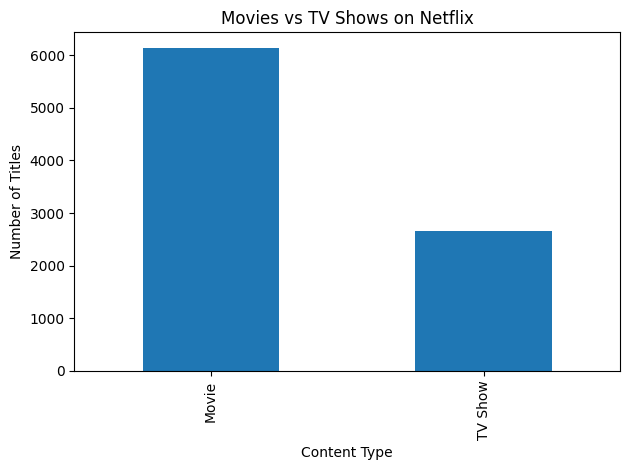

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# ensure the dataframe 'df' exists, otherwise try to load the cleaned CSV
try:
	df  # noqa: F401
except NameError:
	csv_path = Path("../data/prepared/netflix_clean.csv")
	if csv_path.exists():
		df = pd.read_csv(csv_path)
	else:
		raise NameError(f"DataFrame 'df' not found and cleaned CSV not available at: {csv_path}")

type_counts = df["type"].value_counts()

plt.figure()
type_counts.plot(kind="bar")
plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")
plt.tight_layout()
plt.show()


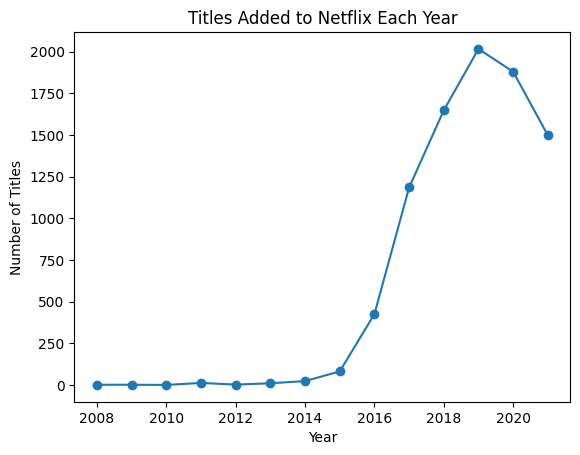

In [5]:
import matplotlib.pyplot as plt
from pathlib import Path

# Ensure df_clean exists; otherwise try to load the cleaned CSV
try:
	df_clean  # noqa: F401
except NameError:
	if csv_path.exists():
		df_clean = pd.read_csv(csv_path)
	else:
		alt_path = Path("../data/prepared/netflix_clean.csv")
		if alt_path.exists():
			df_clean = pd.read_csv(alt_path)
		else:
			raise NameError(f"DataFrame 'df_clean' not found and cleaned CSV not available at: {csv_path} or {alt_path}")

# Make sure date_added is datetime and year_added is available
df_clean["date_added"] = pd.to_datetime(df_clean["date_added"], errors="coerce")
df_clean["year_added"] = df_clean["date_added"].dt.year

titles_per_year = df_clean["year_added"].value_counts().sort_index()

plt.figure()
titles_per_year.plot(kind="line", marker="o")
plt.title("Titles Added to Netflix Each Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()


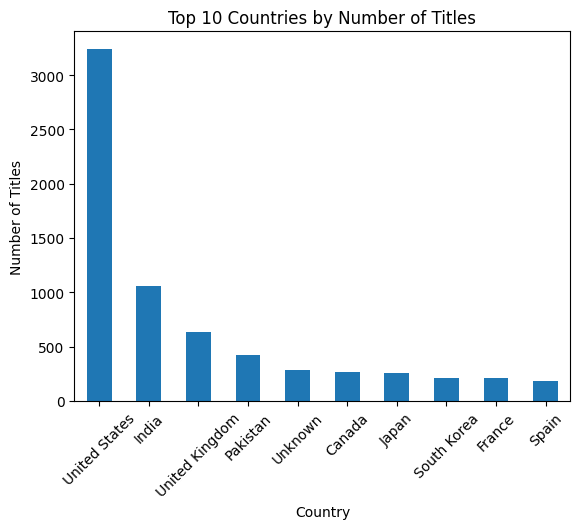

In [6]:
import matplotlib.pyplot as plt

top_countries = (
    df_clean["country"]
    .dropna()
    .str.split(", ")
    .explode()
    .value_counts()
    .head(10)
)

plt.figure()
top_countries.plot(kind="bar")
plt.title("Top 10 Countries by Number of Titles")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.show()


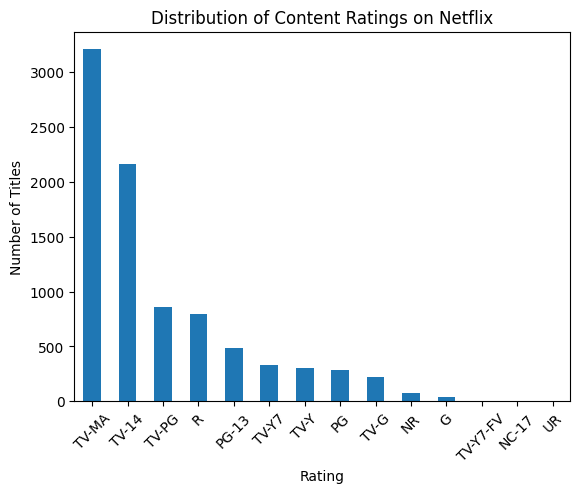

In [7]:
import matplotlib.pyplot as plt

rating_counts = df_clean["rating"].value_counts()

plt.figure()
rating_counts.plot(kind="bar")
plt.title("Distribution of Content Ratings on Netflix")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.show()


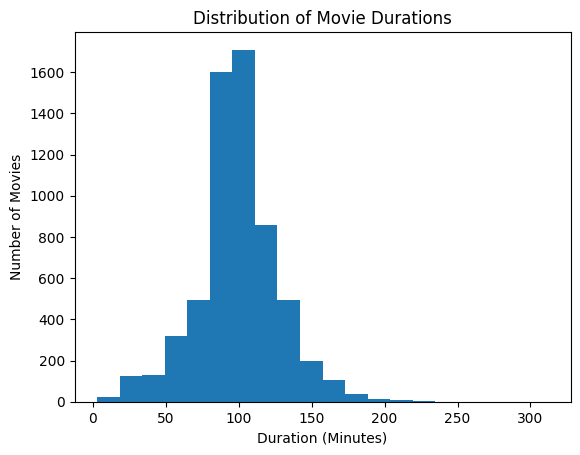

In [8]:
import matplotlib.pyplot as plt

movie_durations = (
    df_clean[df_clean["type"] == "Movie"]["duration"]
    .str.replace(" min", "", regex=False)
    .astype(int)
)

plt.figure()
plt.hist(movie_durations, bins=20)
plt.title("Distribution of Movie Durations")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Movies")
plt.show()


In [ ]:
print("kernel works")
